In [1]:
from fx import *
results = 'data.csv'

In [2]:
#1. get a list of files
files = list(Path('/mnt/4C74F47B74F468DA/Pictures').glob('**/*.JPG'))
print('# files=',len(files))
files += list(Path('/mnt/4C74F47B74F468DA/DCIM').glob('**/*.JPG'))
print('# files=',len(files))
files[:5]

# files= 12760
# files= 13652


[PosixPath('/mnt/4C74F47B74F468DA/Pictures/BKUU7461-2020-11-04 233155.JPG'),
 PosixPath('/mnt/4C74F47B74F468DA/Pictures/BORE1037-2018-10-11 001716.JPG'),
 PosixPath('/mnt/4C74F47B74F468DA/Pictures/BVHR0380-2021-10-05 213751.JPG'),
 PosixPath('/mnt/4C74F47B74F468DA/Pictures/CWII4264-2020-11-04 234258.JPG'),
 PosixPath('/mnt/4C74F47B74F468DA/Pictures/DFCN3364-2021-08-24 221724.JPG')]

In [11]:
#2. save file attributes for re-use
(
    pd.DataFrame({'path':[f for f in files[:]]})
    .assign(sz=lambda x: [file_size(p) for p in x.path])
    .assign(dt=lambda x: [get_exif_data(p)[0] for p in x.path])
    .assign(latlong=lambda x: [get_exif_data(p)[1:] for p in x.path])
    # .assign(latlong=lambda x: [get_lat_lon(p) for p in x.path])
    .to_csv(results,index=False)
)
pd.read_csv(results).head()

,path,sz,dt,latlong
0,/mnt/4C74F47B74F468DA/Pictures/BKUU7461-2020-1...,756288,2020:11:04 17:27:43,"(None, None)"
1,/mnt/4C74F47B74F468DA/Pictures/BORE1037-2018-1...,229622,NaN,"(None, None)"
2,/mnt/4C74F47B74F468DA/Pictures/BVHR0380-2021-1...,291883,2021:10:02 17:55:15,"(None, None)"
3,/mnt/4C74F47B74F468DA/Pictures/CWII4264-2020-1...,584288,2020:11:04 17:32:26,"(None, None)"
4,/mnt/4C74F47B74F468DA/Pictures/DFCN3364-2021-0...,1343071,2021:03:04 14:23:35,"(None, None)"


In [12]:
(
    pd.read_csv(results)
    .assign(has_date=lambda x: x.dt == x.dt)
    .has_date.value_counts()  
)

True     13427
False      225
Name: has_date, dtype: int64

In [13]:
(
    pd.read_csv(results)
    .assign(has_latlong=lambda x: x.latlong.str[:5]!='(None')
    .has_latlong.value_counts()  
)

False    10111
True      3541
Name: has_latlong, dtype: int64

<Axes: xlabel='dt2'>

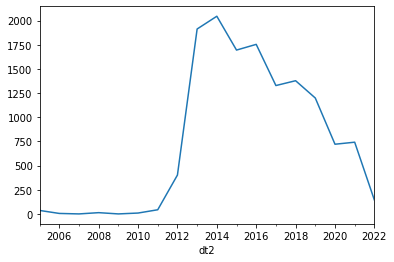

In [18]:
(
    pd.read_csv(results)
    .query(''' dt==dt ''')
    .assign(dt2=lambda x: [datetime.datetime.strptime(s, "%Y:%m:%d %H:%M:%S") for s in x.dt])
    .set_index('dt2').resample('Y')['path'].count().plot()
)
